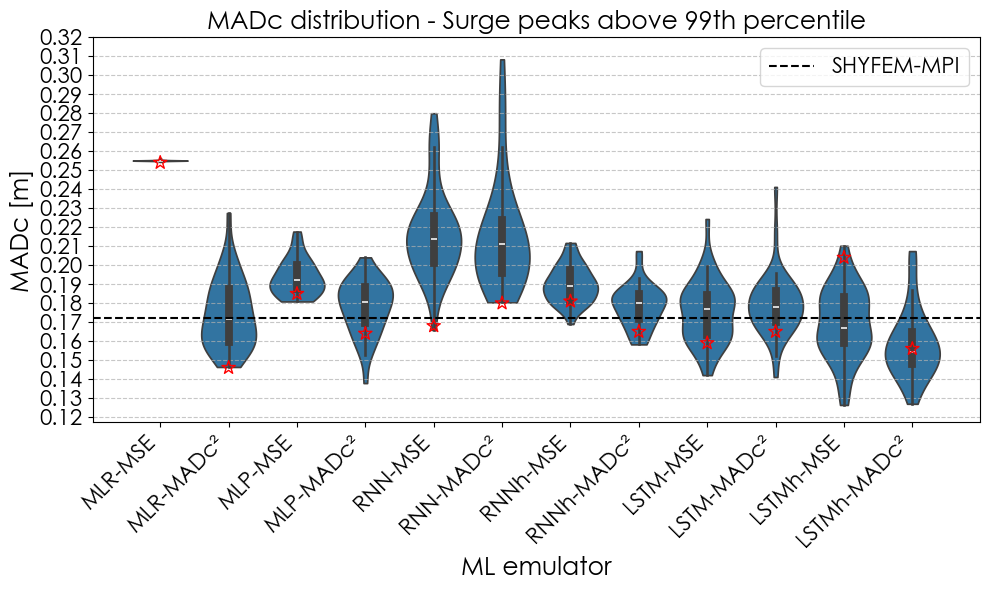

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Load Excel file
excel_path = 'Average_Error_Metrics_Peaks99_All_Emulators.xlsx'
xls = pd.ExcelFile(excel_path)

# Choose the metric to plot
metric_to_plot = 'MADc'  # Change this as needed

# Initialize a list to collect DataFrames
df_list = []

# Loop through each sheet
for sheet_name in xls.sheet_names:
    # Read data and clean column names
    df = pd.read_excel(xls, sheet_name=sheet_name, skiprows=0)
    df.columns = df.columns.str.strip()  # Remove leading/trailing spaces

    if metric_to_plot not in df.columns:
        raise ValueError(f"Metric '{metric_to_plot}' not found in sheet '{sheet_name}'. Available columns: {df.columns.tolist()}")

    # Store the metric and sheet name
    df_metric = pd.DataFrame({
        'Sheet': sheet_name,
        'Value': df[metric_to_plot]
    })
    df_list.append(df_metric)

# Set the font family globally
mpl.rcParams['font.family'] = 'Century Gothic'

# Combine and rename
all_data = pd.concat(df_list, ignore_index=True)
all_data.columns = all_data.columns.str.strip()
# Rename to match plotting code
all_data = all_data.rename(columns={'Sheet': 'ML model', 'Value': 'MADc [m]'})
# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=all_data, x='ML model', y='MADc [m]', inner='box', density_norm='width', cut=0)
# Control axis label font sizes
plt.xlabel('ML emulator', fontsize=18)       # x-axis label
plt.ylabel('MADc [m]', fontsize=18)       # y-axis label
plt.title("MADc distribution - Surge peaks above 99th percentile", fontsize=18)

# Customize x-axis labels
custom_legend_labels = [
    'MLR-MSE', 'MLR-MADc²', 'MLP-MSE', 'MLP-MADc²', 'RNN-MSE', 'RNN-MADc²',
    'RNNh-MSE', 'RNNh-MADc²', 'LSTM-MSE', 'LSTM-MADc²', 'LSTMh-MSE', 'LSTMh-MADc²'
]
plt.xticks(ticks=np.arange(len(custom_legend_labels)), labels=custom_legend_labels, rotation=45, ha='right', fontsize=16)

# Reference line for BC-UniGe
# For MADc:
bcunige = 0.172
# For MADp:
#bcunige = 0.073
# For Bias:
#bcunige = -0.065

plt.axhline(y=bcunige, color='black', linestyle='--', linewidth=1.5, label='SHYFEM-MPI')

# Best performance vector
# For MADc:
values_vector = [0.254,	0.146,	0.185,	0.164,	0.168,	0.180,	0.181,	0.165,	0.159,	0.165,	0.204,	0.156]
# For MADp:
#values_vector = [0.124,	0.058,	0.079,	0.067,	0.072,	0.075,	0.069,	0.060,	0.060,	0.060,	0.087,	0.054]
# For Bias:
#values_vector = [-0.126,	-0.057,	-0.079,	-0.066,	-0.069,	-0.071,	-0.068,	-0.051,	-0.045,	-0.054,	-0.086,	-0.037]

# Plot the stars on top of the violins without fill
for i, value in enumerate(values_vector):
    plt.scatter(i, value, color='red', marker='*', s=100, edgecolor='red', facecolors='none', zorder=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set the y-axis ticks 
# For MADc:
y_min = 0.12
y_max = 0.32
y_ticks = np.arange(y_min, y_max + 0.005, 0.01)  # Ensure it includes y_max if possible
# For MADp:
#y_min = 0.04
#y_max = 0.155
#y_ticks = np.arange(y_min, y_max + 0.005, 0.01)  # Ensure it includes y_max if possible 
# For Bias:
#y_min = -0.16
#y_max = -0.02
#y_ticks = np.arange(y_min, y_max + 0.005, 0.01)  # Ensure it includes y_max if possible

plt.yticks(y_ticks, fontsize=16)

# FOR BIAS:
#plt.gca().invert_yaxis()

# Add legend
plt.legend(loc='upper right', fontsize=16, frameon=True)

plt.tight_layout()

#plt.show()

# Save the figure
# For MADc:
plt.savefig('violinplot_MADc_Peaks', dpi=300, bbox_inches='tight')
# For MADp:
#plt.savefig('violinplot_MADp_Peaks', dpi=300, bbox_inches='tight')
# For Bias:
#plt.savefig('violinplot_Bias_Peaks', dpi=300, bbox_inches='tight')